## WINE QUALITY PREDICTION BY USING CLASSIFICATION


### IMPORTING LIBRARIES

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings .filterwarnings('ignore')

### DATA UNDESTANDING

#### LOADING DATA

In [45]:
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [46]:
data.tail()                

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [47]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [48]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [49]:
data.shape

(1599, 12)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### COUNT OF QUALITY FEATURE

In [51]:
data['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

#### DATA VISUALIZATION

<Axes: xlabel='quality', ylabel='count'>

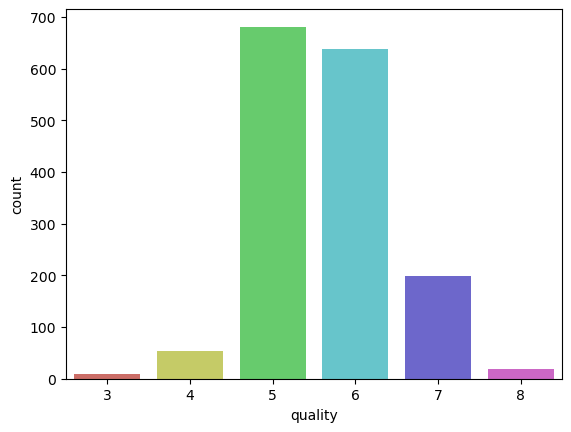

In [52]:
sns.countplot(x=data['quality'],palette='hls')

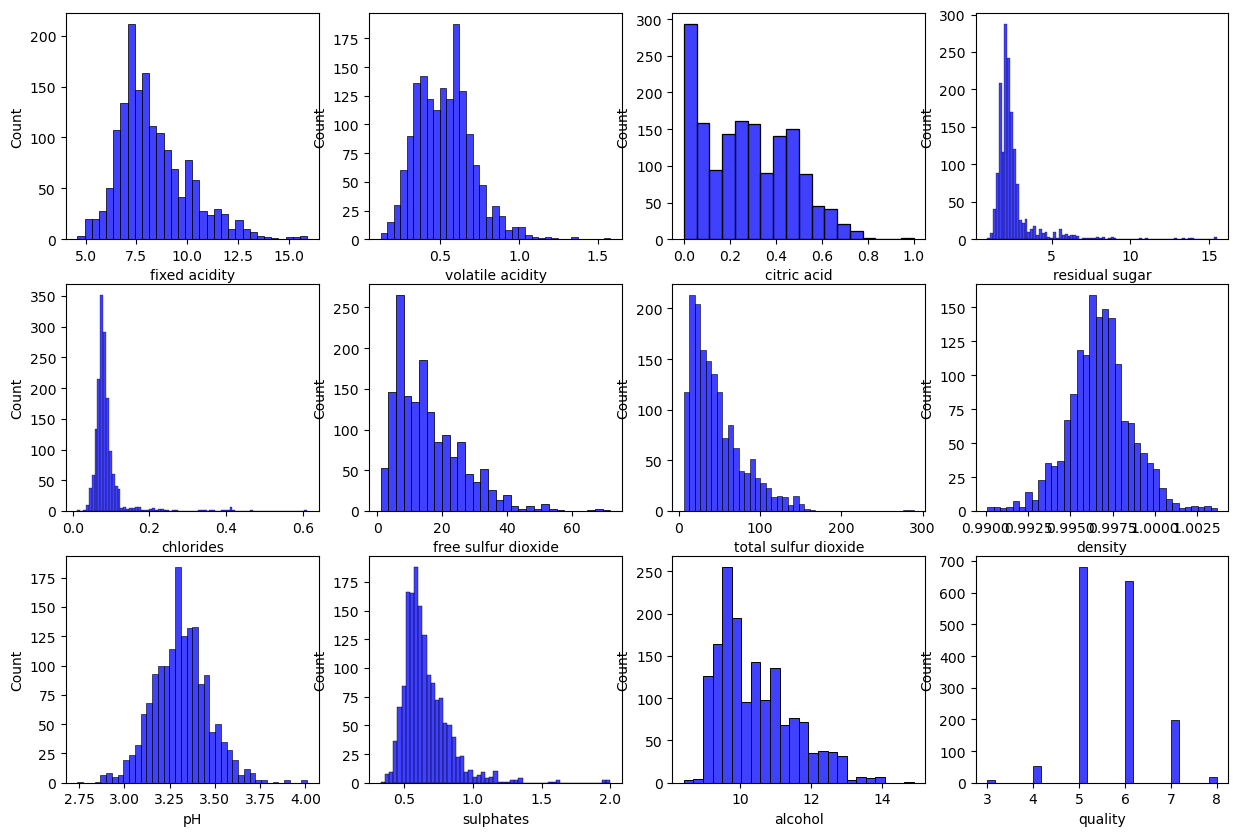

In [53]:

Num_fea = data.select_dtypes(exclude = 'object')
#distrubution of plot each as subplot
fig,axes = plt.subplots(nrows = 3, ncols = 4, figsize=(15,10))
k=0
for i in range(3):
    for j in range(4):
        sns.histplot(data[data.columns[k]], ax = axes[i][j],color = 'blue')
        k+=1



plt.show()

In [54]:
# apply log transform on features
data["residual sugar"]=np.log(data["residual sugar"])
data["chlorides"]=np.log(data["chlorides"])
data["free sulfur dioxide"]=np.log(data["free sulfur dioxide"])
data["total sulfur dioxide"]=np.log(data["total sulfur dioxide"])
data["sulphates"]=np.log(data["sulphates"])

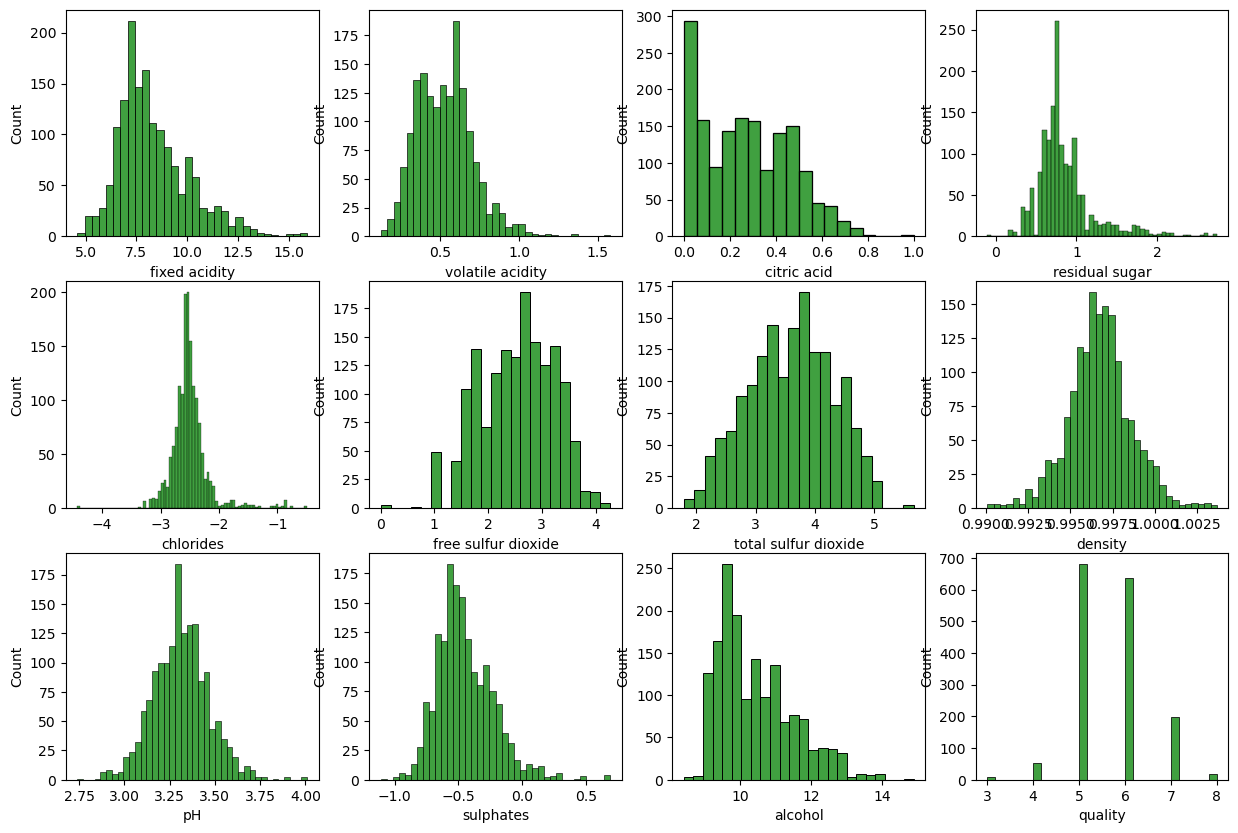

In [56]:

Num_fea = data.select_dtypes(exclude = 'object')
#distrubution of plot each as subplot
fig,axes = plt.subplots(nrows = 3, ncols = 4, figsize=(15,10))
k=0
for i in range(3):
    for j in range(4):
        sns.histplot(data[data.columns[k]], ax = axes[i][j],color = 'green')
        k+=1



plt.show()

## DATA PREPROCESSING

In [57]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [58]:
data.duplicated().sum()

np.int64(240)

In [59]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

## FEATURE SELECTION

In [60]:
X = data.drop('quality',axis='columns')
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [61]:
y = data['quality']
y.head()

0    5
1    5
2    5
3    6
5    5
Name: quality, dtype: int64

#### To find out how much quatity we have

In [62]:
y.value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

### imbalance data: we need convert into balanced data to covert we use imblearn.to install we use pip install imblearn by using upsampling or over sampling

In [63]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
# transform the datset
X,y = oversample.fit_resample(X.fillna(0),y)

In [64]:
y.value_counts()

quality
5    577
6    577
7    577
4    577
8    577
3    577
Name: count, dtype: int64

In [65]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,0.848276,-2.502853,2.547871,3.604522,0.996709,3.309787,-0.444642,10.432315,5.623252
std,1.736990,0.183031,0.195537,0.350004,0.336045,0.683899,0.711538,0.001869,0.155036,0.224199,1.082065,0.823578
min,4.600000,0.120000,0.000000,-0.105361,-4.422849,0.000000,1.791759,0.990070,2.740000,-1.108663,8.400000,3.000000
25%,7.100000,0.390000,0.090000,0.641854,-2.659260,1.945910,3.091042,0.995600,3.210000,-0.597837,9.500000,5.000000
50%,7.900000,0.520000,0.260000,0.788457,-2.538307,2.639057,3.637586,0.996700,3.310000,-0.478036,10.200000,6.000000
75%,9.200000,0.640000,0.430000,0.955511,-2.396896,3.044522,4.143135,0.997820,3.400000,-0.314711,11.100000,6.000000
max,15.900000,1.580000,1.000000,2.740840,-0.492658,4.276666,5.666427,1.003690,4.010000,0.693147,14.900000,8.000000


In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.516176,0.418491,-1.277811,-0.664096,-0.216971,0.052816,0.267978,0.742321,1.137398,-0.603291,-1.144497
1,-0.276444,1.112922,-1.277811,0.241319,0.586889,1.282097,1.239844,0.208721,-0.879053,0.279068,-0.814527
2,-0.276444,0.649968,-1.082086,-0.112589,0.387124,0.517221,0.930792,0.315441,-0.488772,0.074015,-0.814527
3,1.761279,-1.201847,1.462331,-0.664096,-0.258851,0.704632,1.081745,0.849041,-1.139240,-0.443815,-0.814527
4,-0.516176,0.264173,-1.277811,-0.820168,-0.258851,0.302951,0.500824,0.742321,1.137398,-0.603291,-1.144497


In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X ,y , test_size=0.2,random_state=42)

In [68]:
from sklearn .linear_model import LogisticRegression
model_LogReg = LogisticRegression()
model_LogReg.fit(X_train,y_train)
LogReg_acc = round(model_LogReg.score(X_test,y_test)*100)
LogReg_acc

62

In [69]:
#  decission tree regression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
DTR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
DTR_Accuracy

81

In [70]:
# support vector regression
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
SVR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
SVR_Accuracy

88

In [94]:
# random forese regressor with estimate
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(n_estimators=10)
RF_model.fit(X_train, y_train)
from sklearn.metrics import r2_score
RFR_Accuracy=round(r2_score(y_test, RF_model.predict(X_test)) * 100)
RFR_Accuracy

91

In [72]:

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
from sklearn.linear_model import LinearRegression
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
from sklearn.metrics import r2_score
PR_Accuracy=round(r2_score(y_test, poly_model.predict(X_test_poly)) * 100)
PR_Accuracy

81

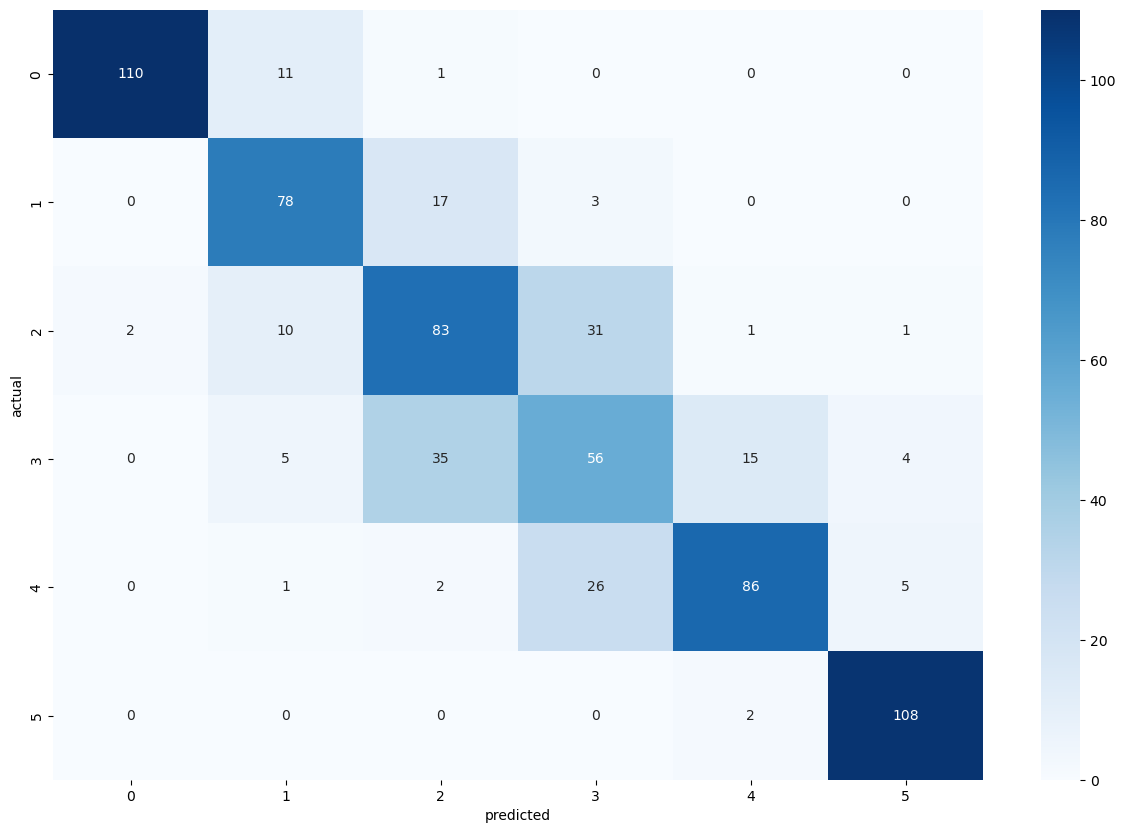

array([[110,  11,   1,   0,   0,   0],
       [  0,  78,  17,   3,   0,   0],
       [  2,  10,  83,  31,   1,   1],
       [  0,   5,  35,  56,  15,   4],
       [  0,   1,   2,  26,  86,   5],
       [  0,   0,   0,   0,   2, 108]])

In [81]:
# heatmap for confusion matrix (ensure cm exists and is 2-D)
from sklearn.metrics import confusion_matrix

try:
    # check if cm is defined and 2-D
    if not ('cm' in globals() and hasattr(cm, "ndim") and cm.ndim == 2):
        raise NameError
except NameError:
    cm = confusion_matrix(y_test,np.round(RF_model.predict(X_test)).astype(int))


plt.figure(figsize=(15,10))
sns.heatmap(cm, annot=True ,fmt='d',cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()
cm

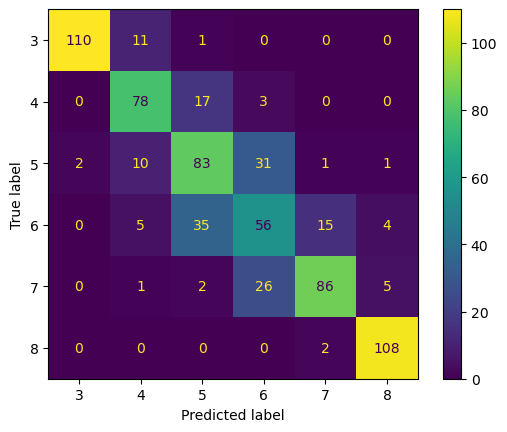

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = [3,4,5,6,7,8])
cm_display.plot()
plt.show()







In [97]:
feature_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol']
feature_values={
    'fixed acidity':7.4,
    'volatile acidity':0.70,
    'citric acid':0.00,
    'residual sugar':0.645738,
    'chlorides':0.9,
    'free sulfur dioxide':0.56,
    'total sulfur dioxide':98,
    'density':1,
    'pH':8,
    'sulphates':6.8,
    'alcohol':5.3
}

# create dataframe with user input 
user_input= pd.DataFrame([feature_values],columns=feature_names)

# scaler
user_input = scaler.transform(user_input)
# make the prediction 
prediction = RF_model.predict(user_input)

print("predicted value", prediction)

predicted value [4.9]


In [98]:
# save scaler
import pickle
filename = 'scaler_model.sav'
pickle.dump(scaler,open(filename, 'wb'))


In [99]:
import pickle
filename = 'finalized_RFmodel.save'
pickle.dump(RF_model,open(filename, 'wb'))